# Tugas Praktikum 1 : Scraping & EDA
Nama : Muhammad Farid Wijdan
NRP : 5054251042

Dataset saya ambil dari web MyAnimeList bagian Top Manga (https://myanimelist.net/topmanga.php). Alasannya karena datanya sudah tabel, banyak, dan gampang di scraping pakai BeautifulSoup. Hasil scraping saya simpan ke `mal_topmanga_raw.csv` dulu biar tidak perlu scraping ulang.

In [41]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import numpy as np

## 1. Scraping Dataset
Saya ambil 1500 data dari 30 halaman (tiap halaman 50 data). Setiap halaman URL-nya `topmanga.php?limit=0, 50, 100, ... 1450`. Kolom yang diambil : rank, judul, tipe, volume, tanggal, members, dan score.

Kode di bawah ini yang saya pakai buat scraping. Sengaja saya matikan (`JALANKAN_SCRAPING = False`) biar waktu di-run tidak nunggu lama, langsung baca file CSV yang sudah ada.

In [42]:
def ambil_halaman(limit):
    url = f"https://myanimelist.net/topmanga.php?limit={limit}"
    headers = {"User-Agent": "Mozilla/5.0 (tugas kuliah)"}
    r = requests.get(url, headers=headers, timeout=20)
    r.raise_for_status()
    return r.text

def parsing(rows_html):
    soup = BeautifulSoup(rows_html, "html.parser")
    hasil = []
    for row in soup.select("tr.ranking-list"):
        rank = int(row.select_one("td.rank span").text.strip())
        a = row.select_one("h3.manga_h3 a")
        judul = a.text.strip()
        link = a["href"]
        manga_id = int(re.search(r"/manga/(\d+)/", link).group(1))
        info = list(row.select_one("div.information").stripped_strings)
        tipe = info[0].split("(")[0].strip()
        vol = re.search(r"(\d+)", info[0])
        volume = int(vol.group(1)) if vol else None
        tanggal = info[1] if len(info) > 1 else ""
        mulai = tanggal.split(" - ")[0].strip()
        selesai = tanggal.split(" - ")[1].strip() if " - " in tanggal else ""
        thn = re.search(r"(\d{4})", mulai)
        tahun_mulai = int(thn.group(1)) if thn else None
        members = int(re.search(r"([\d,]+)", info[2]).group(1).replace(",", ""))
        s = row.select_one("td.score span").text.strip()
        score = float(s) if s != "N/A" else None
        hasil.append([rank, manga_id, judul, link, tipe, volume, tanggal, mulai, selesai, tahun_mulai, members, score])
    return hasil

In [43]:
semua = []
for limit in range(0, 1500, 50):
    print("ambil limit", limit)
    html = ambil_halaman(limit)
    semua.extend(parsing(html))
    time.sleep(2)
kolom = ["rank","manga_id","title","url","type","volumes","date_text","start_text","end_text","start_year","members","score"]
pd.DataFrame(semua, columns=kolom).to_csv("mal_topmanga_raw.csv", index=False)
print("selesai")

ambil limit 0
ambil limit 50
ambil limit 100
ambil limit 150
ambil limit 200
ambil limit 250
ambil limit 300
ambil limit 350
ambil limit 400
ambil limit 450
ambil limit 500
ambil limit 550
ambil limit 600
ambil limit 650
ambil limit 700
ambil limit 750
ambil limit 800
ambil limit 850
ambil limit 900
ambil limit 950
ambil limit 1000
ambil limit 1050
ambil limit 1100
ambil limit 1150
ambil limit 1200
ambil limit 1250
ambil limit 1300
ambil limit 1350
ambil limit 1400
ambil limit 1450
selesai


In [44]:
# baca hasil scraping
df = pd.read_csv("mal_topmanga_raw.csv")
print(df.shape)
df.head(10)

(1500, 12)


,rank,manga_id,title,url,type,volumes,date_text,start_text,end_text,start_year,members,score
0,1,2,Berserk,https://myanimelist.net/manga/2/Berserk,Manga,NaN,Aug 1989 -,Aug 1989 -,NaN,1989.0,808729,9.46
1,2,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,https://myanimelist.net/manga/1706/JoJo_no_Kim...,Manga,24.0,Jan 2004 - Apr 2011,Jan 2004,Apr 2011,2004.0,331059,9.34
2,3,656,Vagabond,https://myanimelist.net/manga/656/Vagabond,Manga,37.0,Sep 1998 - May 2015,Sep 1998,May 2015,1998.0,467180,9.27
3,4,13,One Piece,https://myanimelist.net/manga/13/One_Piece,Manga,NaN,Jul 1997 -,Jul 1997 -,NaN,1997.0,706677,9.21
4,5,162032,Guimi Zhi Zhu,https://myanimelist.net/manga/162032/Guimi_Zhi...,Novel,18.0,May 2020 - Aug 2023,May 2020,Aug 2023,2020.0,26194,9.20
5,6,1,Monster,https://myanimelist.net/manga/1/Monster,Manga,18.0,Dec 1994 - Dec 2001,Dec 1994,Dec 2001,1994.0,294816,9.16
6,7,147272,The Greatest Estate Developer,https://myanimelist.net/manga/147272/The_Great...,Manhwa,NaN,Jul 2021 - Jan 2026,Jul 2021,Jan 2026,2021.0,94715,9.10
7,8,51,Slam Dunk,https://myanimelist.net/manga/51/Slam_Dunk,Manga,31.0,Sep 1990 - Jun 1996,Sep 1990,Jun 1996,1990.0,203546,9.09
8,9,642,Vinland Saga,https://myanimelist.net/manga/642/Vinland_Saga,Manga,29.0,Apr 2005 - Jul 2025,Apr 2005,Jul 2025,2005.0,367227,9.09
9,10,25,Fullmetal Alchemist,https://myanimelist.net/manga/25/Fullmetal_Alc...,Manga,27.0,Jul 2001 - Sep 2010,Jul 2001,Sep 2010,2001.0,327004,9.05


## 2. Pemahaman Dataset
Data ini bentuknya tabel, 1 baris = 1 judul manga.

In [45]:
df.info()
print(df.shape)
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rank        1500 non-null   int64  
 1   manga_id    1500 non-null   int64  
 2   title       1500 non-null   str    
 3   url         1500 non-null   str    
 4   type        1500 non-null   str    
 5   volumes     1040 non-null   float64
 6   date_text   1500 non-null   str    
 7   start_text  1500 non-null   str    
 8   end_text    1114 non-null   str    
 9   start_year  1499 non-null   float64
 10  members     1500 non-null   int64  
 11  score       1500 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 140.8 KB
(1500, 12)
rank            int64
manga_id        int64
title             str
url               str
type              str
volumes       float64
date_text         str
start_text        str
end_text          str
start_year    float64
members         int64
score         flo

Tipe atribut menurut saya :
- Nominal : title, url, type, date_text, start_text, end_text. Soalnya ini kategori/teks biasa, tidak ada urutan.
- Ordinal : status (Ongoing < Finished). Ini saya buat dari end_text, kalau end_text kosong berarti masih ongoing.
- Numerik diskrit : rank, manga_id, volumes, start_year, members (bilangan bulat).
- Numerik kontinu : score (misal 8.13, 9.46).

In [46]:
df["status"] = np.where(df["end_text"].isna(), "Ongoing", "Finished")
df[["title","type","status","score","members"]].head()

,title,type,status,score,members
0,Berserk,Manga,Ongoing,9.46,808729
1,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,Manga,Finished,9.34,331059
2,Vagabond,Manga,Finished,9.27,467180
3,One Piece,Manga,Ongoing,9.21,706677
4,Guimi Zhi Zhu,Novel,Finished,9.20,26194


## 3. Statistik deskriptif
### Numerik

In [47]:
df.describe()

,rank,manga_id,volumes,start_year,members,score
count,1500.000000,1500.000000,1040.000000,1499.000000,1500.000000,1500.000000
mean,750.500000,69902.065333,11.917308,2010.771181,40355.272667,8.128940
std,433.157015,59522.350442,11.018179,9.750167,76578.523574,0.281648
min,1.000000,1.000000,1.000000,1966.000000,464.000000,7.800000
25%,375.750000,8131.500000,3.000000,2005.000000,7197.000000,7.900000
50%,750.500000,63243.000000,9.000000,2012.000000,16286.000000,8.060000
75%,1125.250000,122119.250000,17.000000,2018.000000,37473.500000,8.280000
max,1500.000000,194701.000000,78.000000,2026.000000,808729.000000,9.460000


In [48]:
# rata-rata, median, modus, std, min, max buat score dan members
print("score mean :", df["score"].mean())
print("score median :", df["score"].median())
print("score modus :", df["score"].mode()[0])
print("score std :", df["score"].std())
print("score min :", df["score"].min(), " max :", df["score"].max())
print("members mean :", df["members"].mean())
print("members median :", df["members"].median())
print("members min :", df["members"].min(), " max :", df["members"].max())

score mean : 8.12894
score median : 8.06
score modus : 7.83
score std : 0.28164793645034547
score min : 7.8  max : 9.46
members mean : 40355.272666666664
members median : 16286.0
members min : 464  max : 808729


### Kategorikal

In [49]:
print(df["type"].value_counts())
print(df["status"].value_counts())

type
Manga          1029
Light Novel     203
Manhwa          200
Novel            39
Manhua           19
One-shot         10
Name: count, dtype: int64
status
Finished    1114
Ongoing      386
Name: count, dtype: int64


### Nilai yang hilang

In [58]:
print(df.isnull().sum())
print((df.isnull().sum() / len(df) * 100).round(2))

rank            0
manga_id        0
title           0
url             0
type            0
volumes       460
date_text       0
start_text      0
end_text      386
start_year      1
members         0
score           0
status          0
dtype: int64
rank           0.00
manga_id       0.00
title          0.00
url            0.00
type           0.00
volumes       30.67
date_text      0.00
start_text     0.00
end_text      25.73
start_year     0.07
members        0.00
score          0.00
status         0.00
dtype: float64


Yang hilang banyak itu volumes (460) sama end_text (386). Itu wajar karena di websitenya tertulis `? vols` kalau ongoing, dan end_text kosong kalau masih ongoing. Jadi tidak saya hapus, dibiarkan saja. Cuma 1 data yang start_year-nya hilang.

### Outlier

In [51]:
for kolom in ["score", "members", "volumes"]:
    q1 = df[kolom].quantile(0.25)
    q3 = df[kolom].quantile(0.75)
    iqr = q3 - q1
    bawah = q1 - 1.5 * iqr
    atas = q3 + 1.5 * iqr
    jml = ((df[kolom] < bawah) | (df[kolom] > atas)).sum()
    print(kolom, "outlier :", jml, " batas :", round(bawah,2), "-", round(atas,2))

print()
print("5 members terbesar :")
print(df.nlargest(5, "members")["title"].tolist())

score outlier : 37  batas : 7.33 - 8.85
members outlier : 177  batas : -38217.75 - 82888.25
volumes outlier : 28  batas : -18.0 - 38.0

5 members terbesar :
['Berserk', 'Chainsaw Man', 'Chainsaw Man', 'One Piece', 'Shingeki no Kyojin']


## 4. Visualisasi
### Histogram score dan members

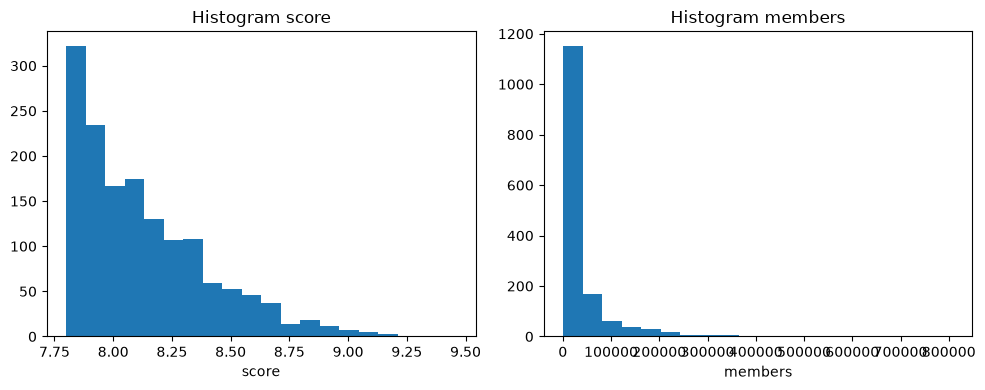

In [52]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df["score"], bins=20)
plt.title("Histogram score")
plt.xlabel("score")
plt.subplot(1,2,2)
plt.hist(df["members"], bins=20)
plt.title("Histogram members")
plt.xlabel("members")
plt.tight_layout()
plt.show()

Dari grafik di atas, score kebanyakan ngumpul di 7.9 - 8.3. Members kebanyakan kecil, yang besar cuma sedikit (misal Berserk sampai 800rb). Jadi datanya miring ke kanan.

### Bar chart tipe

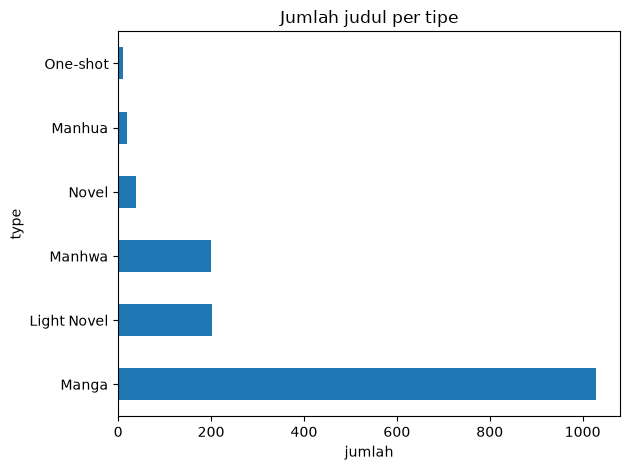

In [53]:
df["type"].value_counts().plot(kind="barh")
plt.title("Jumlah judul per tipe")
plt.xlabel("jumlah")
plt.tight_layout()
plt.show()

Tipe Manga paling banyak (1000+), terus Light Novel sama Manhwa sekitar 200-an. Sisanya dikit.

### Scatter members vs score

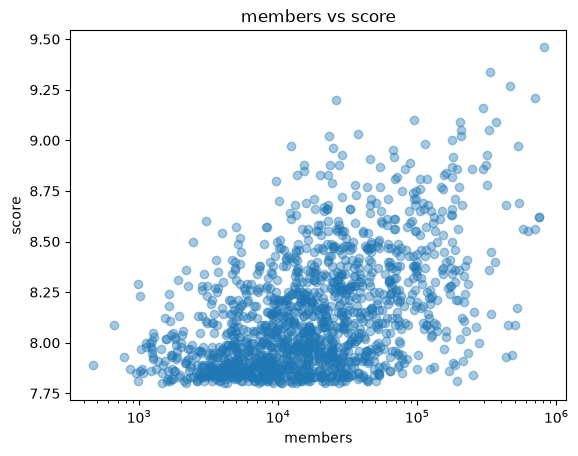

korelasi : 0.421


In [54]:
plt.scatter(df["members"], df["score"], alpha=0.4)
plt.xscale("log")
plt.xlabel("members")
plt.ylabel("score")
plt.title("members vs score")
plt.show()
print("korelasi :", df[["score","members"]].corr().iloc[0,1].round(3))

Titiknya nyebar, tapi yang members-nya besar skornya cenderung agak tinggi. Tapi tidak selalu, banyak juga yang members dikit tapi skor tinggi.

### Heatmap korelasi

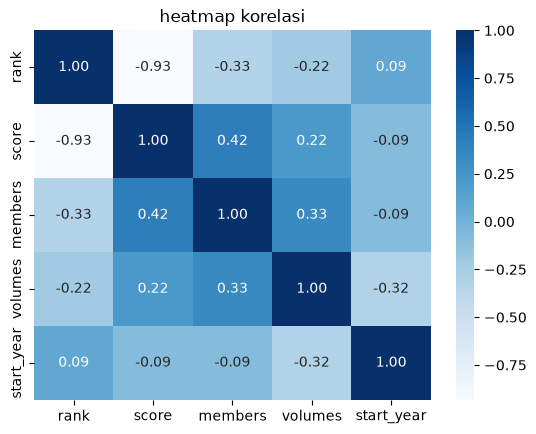

In [55]:
sns.heatmap(df[["rank","score","members","volumes","start_year"]].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("heatmap korelasi")
plt.show()

Yang korelasinya paling kuat cuma rank sama score (negatif), artinya rank kecil = score besar. Masuk akal karena ranking-nya memang dari score. Yang lain korelasinya kecil.

### Boxplot score per tipe

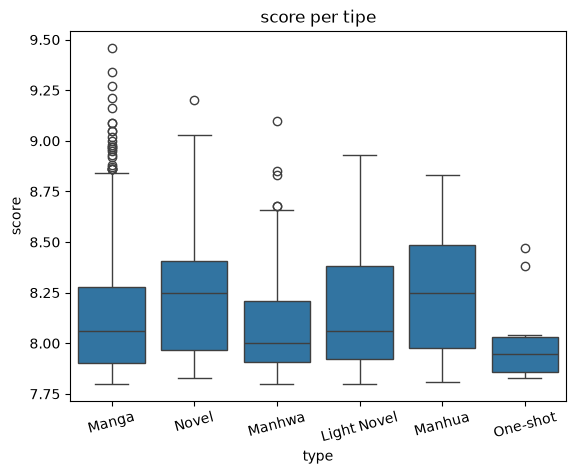

In [56]:
sns.boxplot(data=df, x="type", y="score")
plt.xticks(rotation=15)
plt.title("score per tipe")
plt.show()

Median tiap tipe hampir sama semua, jadi tipe tidak terlalu ngaruh ke score. Outlier yang di atas itu judul-judul yang bagus banget kayak Berserk.

## 5. Laporan singkat
**Deskripsi dataset :** data top 1500 manga dari MyAnimeList, hasil scraping 30 halaman. Kolomnya ada rank, manga_id, title, url, type, volumes, date_text, start_text, end_text, start_year, members, score. Ada 6 tipe, yang paling banyak Manga.

**Statistik :** rata-rata score 8.13, median 8.06, std kecil (0.28). Members rata-rata 40rb tapi median cuma 16rb karena ada beberapa yang besar banget. Type paling banyak Manga (1029), status kebanyakan Finished.

**Penanganan data :** volumes yang kosong (460) dan end_text kosong (386) saya biarkan karena itu artinya ongoing, bukan error. Outlier members banyak tapi tetap dipertahankan karena itu data asli (judul terkenal). Tidak ada duplikat dan score semuanya normal 0-10.

**Insight dari grafik :** score ngumpul di 8-an, members miring kanan. Tipe tidak terlalu pengaruh ke score. Popularitas (members) tidak selalu sama dengan kualitas (score), jadi masih banyak judul yang kurang terkenal tapi skornya tinggi.